In [12]:
# import libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

# set up
pd.set_option('display.max_columns', None)

In [13]:
# Load data

merged = pd.read_csv('~/DSP_group_project_avian_datasets/data/processed/merged.csv')
colours = pd.read_csv('~/DSP_group_project_avian_datasets/data/processed/colours_unmatched.csv')

path = os.path.expanduser('~/DSP_group_project_avian_datasets/data/processed/bird_list.txt')

with open(path, 'r') as f:
    birds = [line.strip() for line in f]


/tmp/ipykernel_27809/2461849300.py:3: DtypeWarning: Columns (51,52,53,54,55,56,74,76) have mixed types. Specify dtype option on import or set low_memory=False.
  merged = pd.read_csv('~/DSP_group_project_avian_datasets/data/processed/merged.csv')


In [18]:
merged.columns.to_list()

['English Name (BirdLife > IOC > Clements>AviList)',
 'scientific_name',
 'Order_x',
 'Family IOC 15.1',
 'Genus',
 'Species',
 '2024 IUCN Red List category',
 'RR',
 'ISL',
 'RLM',
 'LAT',
 'Female MinMass',
 'Female MaxMass',
 'Male MinMass',
 'Male MaxMass',
 'Unsexed MinMass',
 'Unsexed MaxMass',
 'Average Mass',
 'NormMin',
 'Elevational Range',
 'NormMax',
 'F',
 'BM',
 'WD',
 'SH',
 'SV',
 'G',
 'PL',
 'R',
 'D',
 'A',
 'RV',
 'C',
 'W',
 'SE',
 'O',
 'Primary Habitat',
 'HB',
 'Primary Diet',
 'IN-Wt',
 'FR-Wt',
 'NE-Wt',
 'SE-Wt',
 'VE-Wt',
 'FI-Wt',
 'SC-Wt',
 'PL-Wt',
 'MS-Wt',
 'SUM-Wt',
 'DB',
 'ESI',
 'Social_1',
 'Social_2',
 'Social_3',
 'Social_4',
 'Social_5',
 'Social_6',
 'Mono',
 'Poly',
 'Coop',
 'Nest_Type',
 'Nest_SBS',
 'Brd1',
 'Brd2',
 'Clutch_Min',
 'Clutch_Max',
 'Incu_Sex',
 'Incu1',
 'Incu2',
 'Fldg1',
 'Fldg2',
 'Para.1',
 'Para.2',
 'BrS1',
 'BrS2',
 'Prod1',
 'Prod2',
 'Flightlessness',
 'Mig',
 'Alt',
 'Irreg',
 'Disp',
 'Sed',
 'Beak.Length_Culmen',


In [5]:
results_dir = os.path.expanduser("~/DSP_group_project_avian_datasets/results/distributions")
os.makedirs(results_dir, exist_ok=True)

numeric_cols = ['Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width',  'Beak.Depth', 'Tarsus.Length', 'Wing.Length', 
                'Kipps.Distance', 'Secondary1', 'Tail.Length']

for col in numeric_cols:
    plt.figure()
    plt.hist(merged[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col} (in mm) Distribution")
    plt.xlabel(col)         
    plt.ylabel("Frequency")
    file_path = os.path.join(results_dir, f"{col}_distribution.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')

    plt.close()

In [9]:


numeric_cols = ['Mass', 'Average Mass', 'Female MinMass', 'Female MaxMass', 'Male MinMass', 'Male MaxMass', 'Unsexed MinMass', 'Unsexed MaxMass']

for col in numeric_cols:
    plt.figure()
    plt.hist(merged[col].dropna(), bins=100, color='forestgreen', edgecolor='black')
    plt.autoscale(axis='x')
    plt.title(f"{col} (in g) Distribution")
    plt.xlabel(col)         
    plt.ylabel("Frequency")
    file_path = os.path.join(results_dir, f"{col}_distribution.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')

    plt.close()


ESI_col = ['ESI','Hand-Wing.Index']
for col in ESI_col:
    plt.figure()
    plt.hist(merged[col].dropna(), bins=100, color='gold', edgecolor='black')
    plt.autoscale(axis='x')
    plt.title(f"{col} Distribution")
    plt.xlabel(col)         
    plt.ylabel("Frequency")
    file_path = os.path.join(results_dir, f"{col}_distribution.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')

    plt.close()


In [7]:
max_value = merged['Female MinMass'].max()
min_value = merged['Female MinMass'].min()
print(min_value, max_value)

1.9 100000.0


In [33]:

results_dir = os.path.expanduser("~/DSP_group_project_avian_datasets/results/distributions")
os.makedirs(results_dir, exist_ok=True)

categorical_cols = [ 'Order_x', 'Family IOC 15.1',  '2024 IUCN Red List category',  'Primary Habitat',  'Primary Diet', 'Trophic.Level',  'Trophic.Niche',
                     'Primary.Lifestyle', 'RLM','LAT','RR', 'Flightlessness']

for col in categorical_cols:
    plt.figure()
    
    counts = merged[col].value_counts().head(15)
    plt.bar(counts.index.astype(str), counts.values, color='coral', edgecolor='black')
    
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.xticks(rotation=45, ha='right')
    
    file_path = os.path.join(results_dir, f"{col}_distribution.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    
    plt.close()

In [ ]:
# Managing the mass by averaging from the 2 datasets
merged['Mass_combined'] = merged[['Mass', 'Average Mass']].mean(axis=1, skipna=True)
merged['Female_Mass_combined'] = merged[['Female MinMass', 'Female MaxMass']].mean(axis=1, skipna=True)
merged['Male_Mass_combined']   = merged[['Male MinMass', 'Male MaxMass']].mean(axis=1, skipna=True)
merged['Unsexed_Mass_combined'] = merged[['Unsexed MinMass', 'Unsexed MaxMass']].mean(axis=1, skipna=True)


In [16]:
for col in ['Mass', 'Average Mass', 'Female MinMass', 'Female MaxMass', 
            'Male MinMass', 'Male MaxMass', 'Unsexed MinMass', 'Unsexed MaxMass']:
    merged[col] = np.log1p(merged[col])

In [55]:
iucn_labels = {
    'EX': 'Extinct',
    'EW': 'Extinct in the Wild',
    'CR (PE)': 'Possibly Extinct',
    'CR (PEW)': 'Possibly Extinct in the Wild',
    'CR': 'Critically Endangered',
    'EN': 'Endangered',
    'VU': 'Vulnerable',
    'NT': 'Near-threatened',
    'LC': 'Least Concern',
    'DD': 'Data Deficient'
}

# Create a new column with full labels
merged['IUCN_full'] = merged['2024 IUCN Red List category'].map(iucn_labels)

In [58]:
numeric_cols = [
    'Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width', 'Beak.Depth', 
    'Tarsus.Length', 'Wing.Length', 'Kipps.Distance', 'Secondary1', 'Tail.Length',
    'Mass_combined', 
    'ESI', 
    'Hand-Wing.Index'
]

dropped_na_rows = merged[numeric_cols].dropna()

merged_complete = merged.loc[dropped_na_rows.index]
print(merged_complete.shape)
print(merged.shape)

(10690, 113)
(11589, 113)


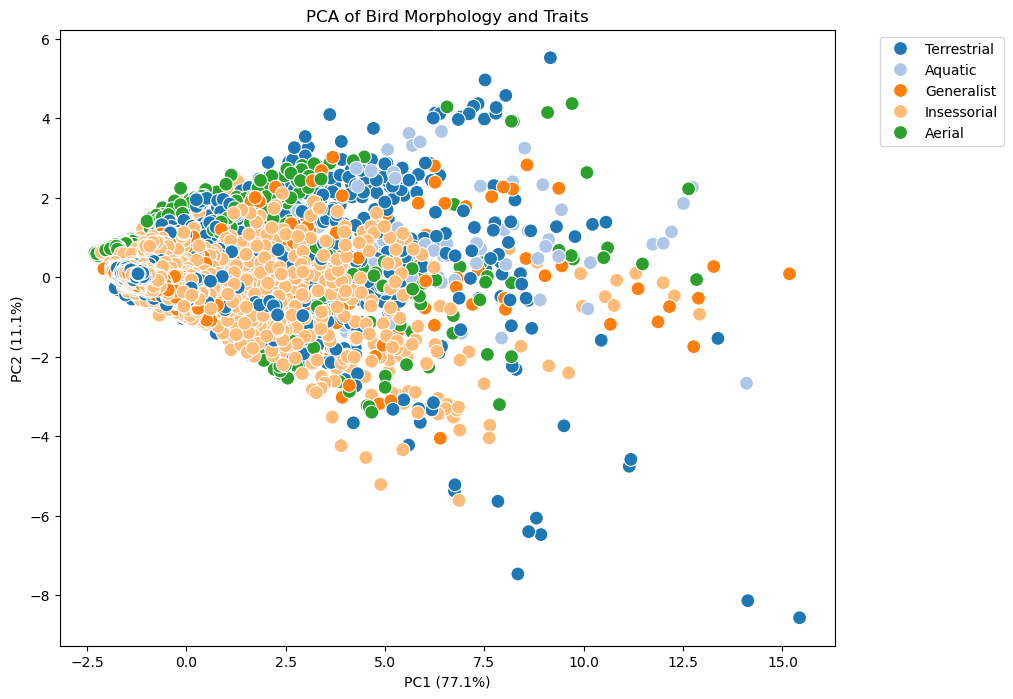

In [31]:
# PCA

numeric_cols = [
    #'Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width', 'Beak.Depth', 
    'Tarsus.Length', 'Wing.Length', 'Kipps.Distance', 'Secondary1', 'Tail.Length',
    #'Mass_combined', 
    #'ESI', 
    #'Hand-Wing.Index'
]

df_pca_ready = merged[numeric_cols].dropna()
merged_complete = merged.loc[df_pca_ready.index]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(merged_complete[numeric_cols])



pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(pcs, columns=['PC1', 'PC2'])
df_pca['Family'] = merged_complete['Primary.Lifestyle'] 

plt.figure(figsize=(10,8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Family', palette='tab20', s=100)
plt.title('PCA of Bird Morphology and Traits')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [23]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1','PC2'], index=numeric_cols)
print(loadings)

                      PC1       PC2
Tarsus.Length    0.399059 -0.299809
Wing.Length      0.491511  0.018585
Kipps.Distance   0.425880  0.388546
Secondary1       0.459576 -0.275598
Tail.Length      0.392999 -0.247883
ESI             -0.110938 -0.123851
Hand-Wing.Index  0.199575  0.778500


/tmp/ipykernel_27809/448966831.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_complete, x='IUCN_full', y='Abundance estimate', palette='Set2')


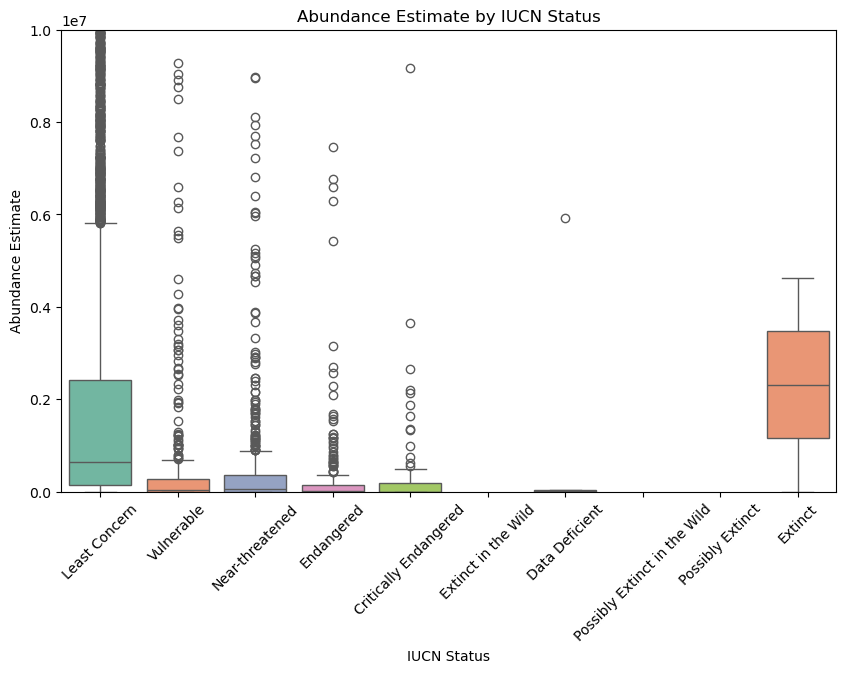

In [64]:
plt.figure(figsize=(10,6))
sns.boxplot(data=merged_complete, x='IUCN_full', y='Abundance estimate', palette='Set2')
plt.xlabel('IUCN Status')
#plt.yscale('log')
plt.ylim(0, 1e7)
plt.ylabel('Abundance Estimate')
plt.title('Abundance Estimate by IUCN Status')
plt.xticks(rotation=45)
plt.savefig("../results/plots/abundance_IUCN.png")
plt.show()

In [ ]:
merged_complete[merged_complete['2024 IUCN Red List category']=='EX'][['scientific_name','Abundance estimate','2024 IUCN Red List category']]
# The extinct thing is coming from a single data

,scientific_name,Abundance estimate,2024 IUCN Red List category
8575,zosterops conspicillatus,661.0,EX
8583,zosterops albogularis,NaN,EX
9352,turdus poliocephalus,4635607.0,EX
10505,psittirostra psittacea,NaN,EX
10520,hemignathus hanapepe,NaN,EX
10521,hemignathus affinis,NaN,EX
10529,loxops ochraceus,NaN,EX
